In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from dotenv import load_dotenv

load_dotenv()

from sqlalchemy import create_engine
import os

def connect_to_db():
    engine = create_engine(
        f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@"
        f"{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
    )
    return engine

In [3]:
engine = connect_to_db()

conn = engine.connect()

In [4]:
df = pd.read_sql("SELECT * FROM public.gold_model_dataset", engine)

df.head()

,user_id,is_mobile,is_package,channel,cnt,trip_type,is_family_trip,is_multi_room,total_guests,stay_duration,...,avg_session_intensity,avg_stay_duration,avg_advance_booking_days,mobile_usage_rate,destination_booking_rate,destination_popularity,cluster_booking_rate,cluster_popularity,hotel_cluster,is_booking
0,14,0,0,9,1,solo,0,0,1,2,...,1.0,2.0,54.0,0.0,0.0697,3544,0.0341,264,88,0
1,38,0,0,2,1,group,0,0,2,4,...,1.0,4.0,123.0,0.0,0.1277,47,0.1001,1129,33,0
2,40,0,0,0,1,solo,0,0,1,1,...,1.0,1.0,1.0,0.0,0.1000,100,0.0655,885,76,0
3,156,0,0,5,1,family,1,0,4,1,...,1.0,1.0,14.0,0.0,0.1215,214,0.1317,896,13,0
4,156,0,0,5,1,family,1,0,4,1,...,1.0,1.0,14.0,0.0,0.1215,214,0.1143,1260,16,0


In [5]:
aggregated_features = [
    "user_booking_rate",
    "avg_session_intensity",
    "avg_stay_duration",
    "avg_advance_booking_days",
    "mobile_usage_rate",
    "destination_booking_rate",
    "destination_popularity",
    "cluster_booking_rate",
    "cluster_popularity"
]

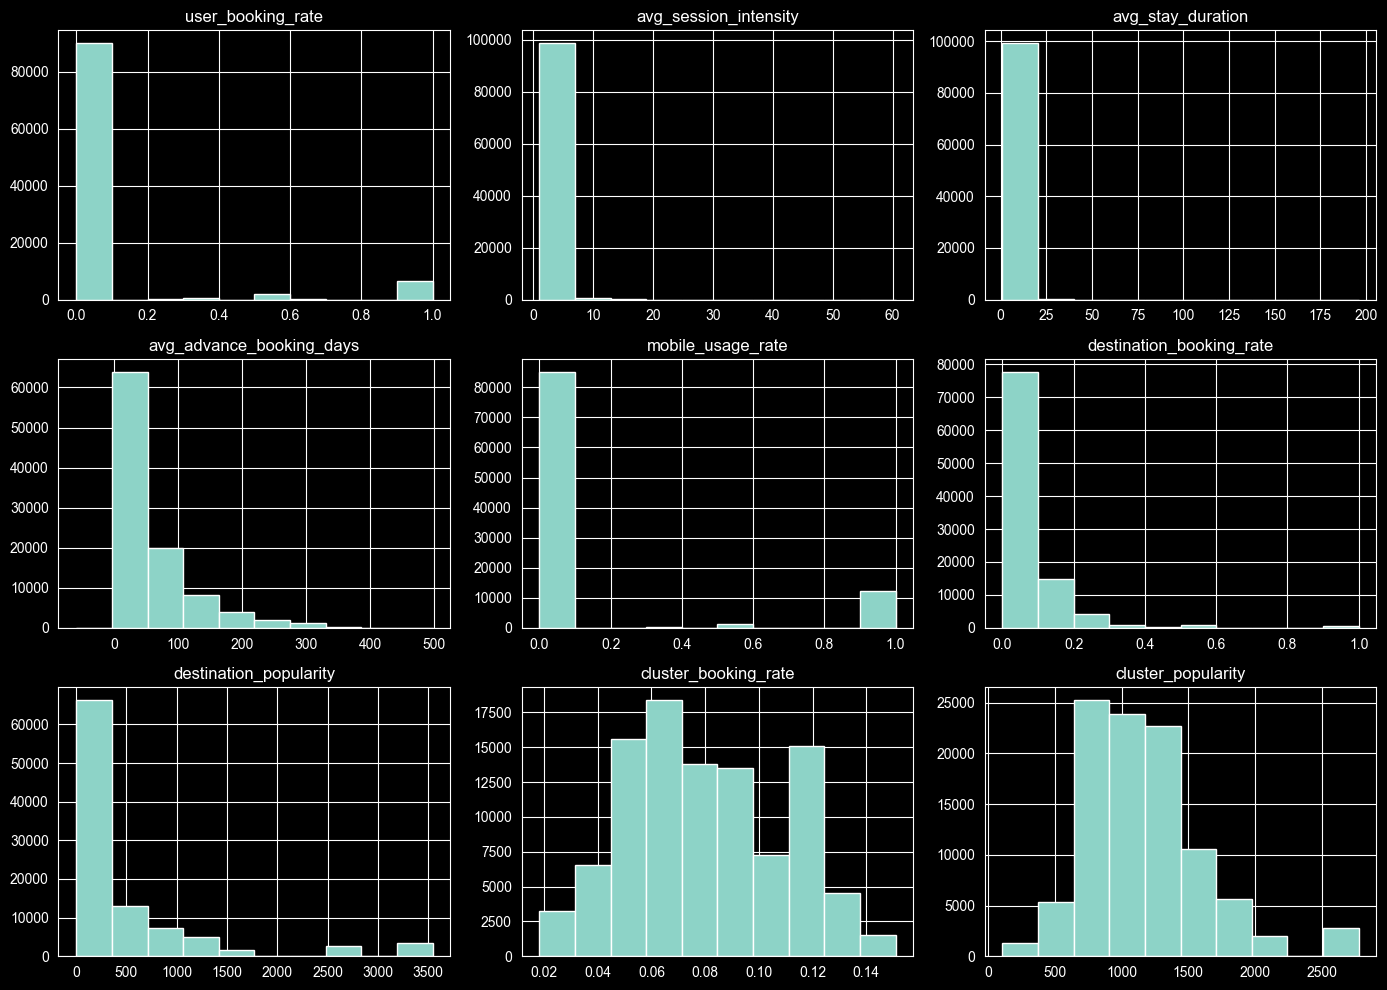

In [6]:
df[aggregated_features].hist(figsize=(14, 10))
plt.tight_layout()

In [7]:
def plot_feature_vs_target(feature, bins=10):
    temp = df[[feature, "is_booking"]].copy()
    temp["bin"] = pd.qcut(temp[feature], q=bins, duplicates="drop")

    grouped = temp.groupby("bin")["is_booking"].mean()

    grouped.plot(kind="bar", figsize=(10,4))
    plt.title(f"{feature} vs Booking Rate")
    plt.ylabel("Booking Rate")
    plt.xticks(rotation=45)
    plt.show()

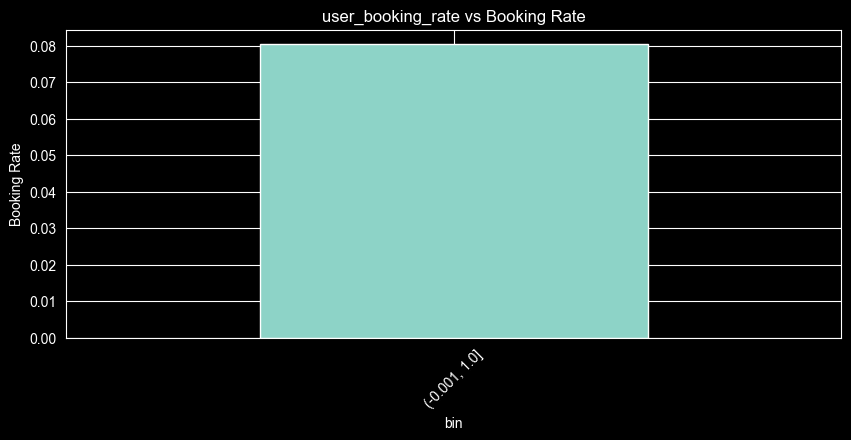

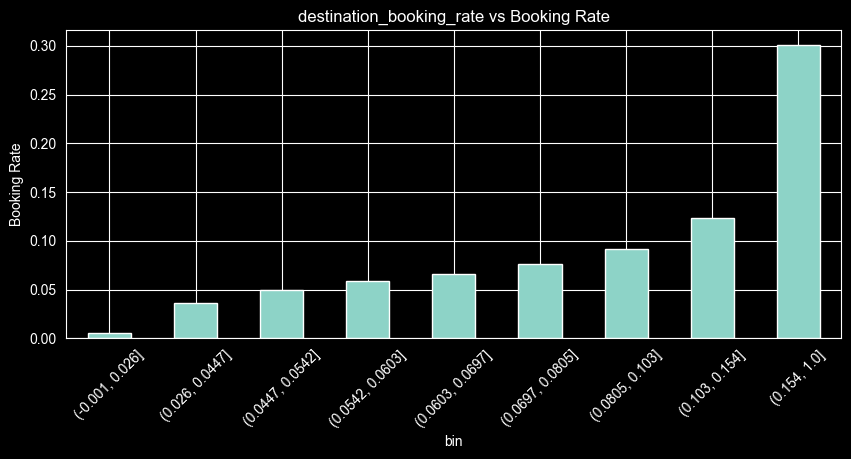

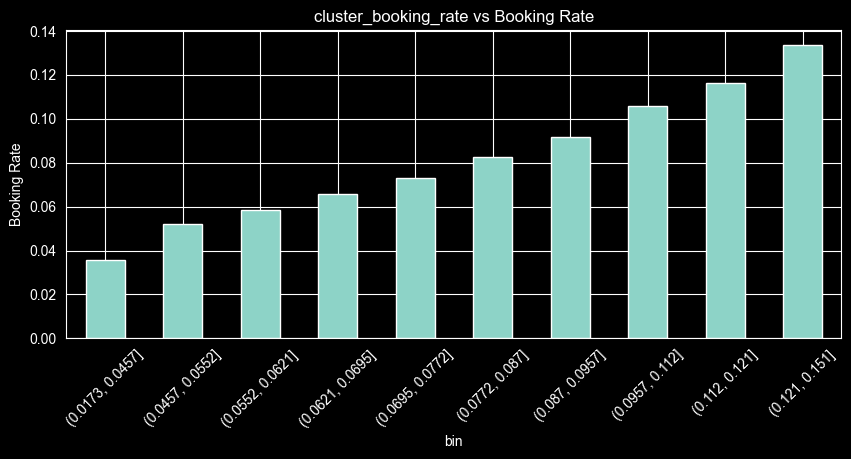

In [8]:
plot_feature_vs_target("user_booking_rate")
plot_feature_vs_target("destination_booking_rate")
plot_feature_vs_target("cluster_booking_rate")

In [9]:
corr = df[aggregated_features + ["is_booking"]].corr()

corr["is_booking"].sort_values(ascending=False)

is_booking                  1.000000
user_booking_rate           0.952633
destination_booking_rate    0.379077
cluster_booking_rate        0.105963
cluster_popularity          0.034252
mobile_usage_rate          -0.027733
destination_popularity     -0.041200
avg_advance_booking_days   -0.083549
avg_stay_duration          -0.094918
avg_session_intensity      -0.107773
Name: is_booking, dtype: float64

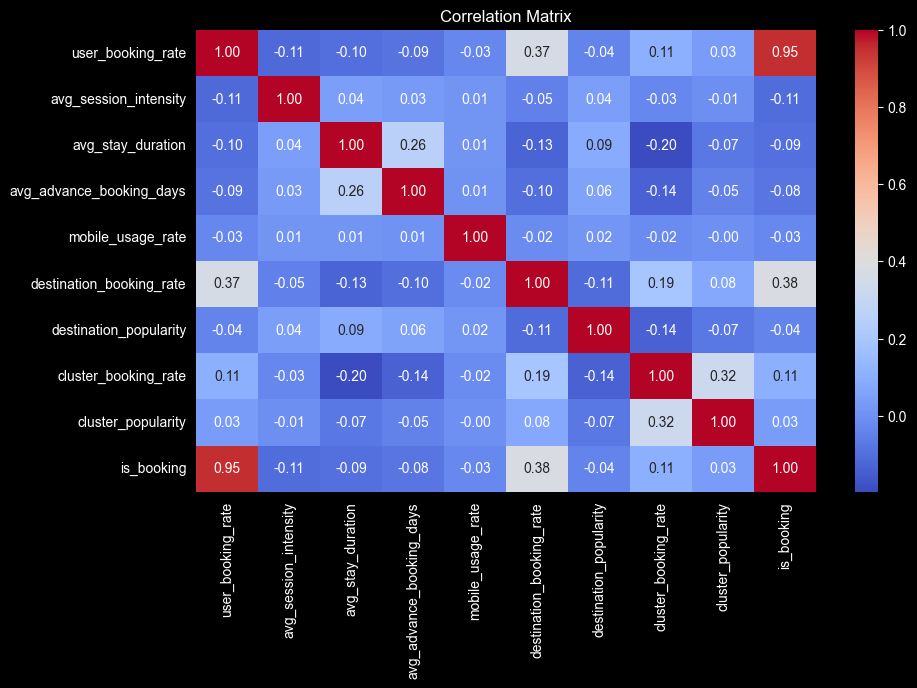

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [11]:
df[["cluster_booking_rate", "is_booking"]].head()

,cluster_booking_rate,is_booking
0,0.0341,0
1,0.1001,0
2,0.0655,0
3,0.1317,0
4,0.1143,0


In [12]:
df["user_high"] = df["user_booking_rate"] > df["user_booking_rate"].median()

df.groupby("user_high")["is_booking"].mean()

user_high
False    0.000000
True     0.840627
Name: is_booking, dtype: float64

In [13]:
conn.close()